In [1]:
print('tests')

tests


In [2]:
import os

# 1. 현재 주피터 노트북의 실행 위치 확인
print(f"현재 위치: {os.getcwd()}")

# 2. 현재 폴더에 무엇이 있는지 확인
print(f"현재 폴더 내용: {os.listdir('.')}")

# 3. 상위 폴더나 하위 폴더에 raw_ml이 있는지 확인
possible_paths = [
    '../raw_ml/서울시 자전거 편의시설.csv',
    './raw_ml/서울시 자전거 편의시설.csv',
    './data/raw_ml/서울시 자전거 편의시설.csv'
]

for path in possible_paths:
    if os.path.exists(path):
        print(f"✅ 파일을 찾았습니다! 사용할 경로: {path}")
        break
else:
    print("❌ 파일을 찾지 못했습니다. 폴더 구조를 다시 확인해야 합니다.")

현재 위치: c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\kride-project
현재 폴더 내용: ['0330_taas_data.ipynb', '0331_taas_data. copy.ipynb', '0331_taas_data..ipynb', 'data', 'db_schema.sql', 'docker-compose.yml', 'ml-server']
✅ 파일을 찾았습니다! 사용할 경로: ./data/raw_ml/서울시 자전거 편의시설.csv


In [3]:
import pandas as pd
import os

# 1. 파일 경로 설정
raw_file_path = './data/raw_ml/서울시 자전거 편의시설.csv'

try:
    df = pd.read_csv(raw_file_path, encoding='cp949')
except:
    df = pd.read_csv(raw_file_path, encoding='utf-8')

print(f"원본 데이터 로드 완료: {len(df)}건")

# 2. 데이터 필터링 (편의시설 컬럼명에 맞게 수정)
# x 좌표(경도), y 좌표(위도)가 있는 행만 남깁니다.
df_clean = df.dropna(subset=['x 좌표', 'y 좌표']).copy()

# 숫자형으로 변환 (좌표 데이터 정규화)
df_clean['x 좌표'] = pd.to_numeric(df_clean['x 좌표'], errors='coerce')
df_clean['y 좌표'] = pd.to_numeric(df_clean['y 좌표'], errors='coerce')

# 다시 한 번 결측치 제거 (숫자로 못 바꾼 값들)
df_clean = df_clean.dropna(subset=['x 좌표', 'y 좌표'])

print(f"필터링 완료 (편의시설 데이터): {len(df_clean)}건")

# 3. 저장 설정
target_dir = '../raw_ml'
file_name = 'seoul_bicycle_amenities_clean.csv' # 파일명 구분
save_path = os.path.join(target_dir, file_name)

if not os.path.exists(target_dir):
    os.makedirs(target_dir)

# 4. 파일 저장
try:
    df_clean.to_csv(save_path, index=False, encoding='utf-8-sig')
    print(f"✅ 성공! 편의시설 데이터가 저장되었습니다: {save_path}")
except Exception as e:
    print(f"❌ 저장 중 오류 발생: {e}")

# 컬럼 확인용
print("\n--- 주요 데이터 샘플 ---")
print(df_clean[['컨텐츠 명', 'x 좌표', 'y 좌표', '구 주소']].head())

원본 데이터 로드 완료: 3368건
필터링 완료 (편의시설 데이터): 3368건
✅ 성공! 편의시설 데이터가 저장되었습니다: ../raw_ml\seoul_bicycle_amenities_clean.csv

--- 주요 데이터 샘플 ---
             컨텐츠 명        x 좌표       y 좌표                 구 주소
0        자전거 일반거치대  126.950520  37.544413    서울특별시 마포구 공덕동 467
1  IBK기업은행 도곡팰리스 옆  127.050743  37.487111    서울특별시 강남구 도곡동 466
2           갈말근린공원  127.053270  37.665810  서울특별시 노원구 상계동 656-1
3       강남구도시관리공단앞  127.051807  37.516347     서울특별시 강남구 삼성동 66
4     강남구립개포꿈하늘도서관  127.080635  37.490793  서울특별시 강남구 일원동 741-4


In [4]:
# 첫 번째 행 선택 (인덱스 0)
first_row = df.iloc[0]
print(first_row)

# 두 번째 열 선택  
# iloc[행.열]
# iloc의 i는 index를 뜻한다 
age_column = df.iloc[:, 1]
print(age_column)

# 첫 번째 행부터 두 번째 행까지, 모든 열 선택
subset = df.iloc[0:2, :]
print(subset)

순서                                                          1
시설ID                                               공덕전철역 2번출구
컨텐츠 명                                               자전거 일반거치대
사용유무                                                       사용
테마 타입                                                      일반
x 좌표                                                126.95052
y 좌표                                                37.544413
좌표 배열                                                      []
좌표타입                                                    Point
메인 이미지                                                    NaN
새 주소                                       서울특별시 마포구 마포대로 109
구 주소                                        서울특별시 마포구 공덕동 467
우편번호                                                   4146.0
국가 지점 번호                                                  NaN
테마 명                                            (친환경)자전거 편의시설
거리                                                3120.858685
업데이트 일  

다음 단계 추천
데이터 통합: 도로 데이터와 편의시설 데이터를 위경도 좌표 기준으로 결합하는 'Spatial Join(공간 결합)' 파이썬 코드가 필요합니다.
안전 점수 정의: 사고 데이터(다발지역)를 불러와서, 사고 좌표와 도로 좌표를 매칭하는 작업을 시작해야 합니다. 

In [5]:
import pandas as pd
import os

# 1. 파일 불러오기
raw_file_path = './data/raw_ml/서울시 자전거 편의시설.csv'

try:
    df = pd.read_csv(raw_file_path, encoding='cp949')
except:
    df = pd.read_csv(raw_file_path, encoding='utf-8')

print(f"입력 데이터 전체 크기: {df.shape}") # (행, 열) 출력

# 2. 모든 행이 NaN(Null)인 열만 삭제 (데이터가 조금이라도 있으면 유지)
# axis=1 은 '열'을 의미, how='all'은 '모든 값이 Null일 때'를 의미
df_reduced = df.dropna(axis=1, how='all')

# 3. 위치 기반 서비스이므로 좌표(x, y)가 아예 없는 행은 제거 (데이터 정합성)
df_clean = df_reduced.dropna(subset=['x 좌표', 'y 좌표']).copy()

# 4. 숫자형 좌표 데이터 정제
df_clean['x 좌표'] = pd.to_numeric(df_clean['x 좌표'], errors='coerce')
df_clean['y 좌표'] = pd.to_numeric(df_clean['y 좌표'], errors='coerce')
df_clean = df_clean.dropna(subset=['x 좌표', 'y 좌표'])

print(f"유효 데이터 필터링 완료: {df_clean.shape}")
print(f"삭제된 '완전 빈 열' 개수: {df.shape[1] - df_clean.shape[1]}개")

# 5. 저장 설정
target_dir = '../raw_ml'
file_name = 'seoul_bicycle_amenities_full_columns.csv'
save_path = os.path.join(target_dir, file_name)

if not os.path.exists(target_dir):
    os.makedirs(target_dir)

# 6. 저장
df_clean.to_csv(save_path, index=False, encoding='utf-8-sig')

print(f"✅ 저장 완료: {save_path}")
print("\n--- 유지된 컬럼 목록 ---")
print(df_clean.columns.tolist())

입력 데이터 전체 크기: (3368, 47)
유효 데이터 필터링 완료: (3368, 40)
삭제된 '완전 빈 열' 개수: 7개
✅ 저장 완료: ../raw_ml\seoul_bicycle_amenities_full_columns.csv

--- 유지된 컬럼 목록 ---
['순서', '시설ID', '컨텐츠 명', '사용유무', '테마 타입', 'x 좌표', 'y 좌표', '좌표 배열', '좌표타입', '메인 이미지', '새 주소', '구 주소', '우편번호', '국가 지점 번호', '테마 명', '거리', '업데이트 일', '등록일', '이미지 URL1', '이미지 URL2', '상세정보 이름 1', '상세정보 값 1', '상세정보 이름 2', '상세정보 값 2', '상세정보 이름 3', '상세정보 값 3', '상세정보 이름 4', '상세정보 값 4', '상세정보 이름 5', '상세정보 값 5', '상세정보 이름 6', '상세정보 값 6', '상세정보 이름 7', '상세정보 값 7', '상세정보 이름 8', '상세정보 값 8', '상세정보 이름 9', '상세정보 값 9', '상세정보 이름 10', '상세정보 값 10']


In [ ]:
# 1. 특정 컬럼(y 좌표)이 비어있는 '행'들만 직접 확인하기
# 도로 데이터의 '기점위도' 대신 'y 좌표'를 사용합니다.DD
missing_y_rows = df[df['y 좌표'].isnull()]
print("--- [y 좌표]가 비어있는 행들 ---")
display(missing_y_rows) # 데이터가 없다면 빈 표가 나옵니다.

# 2. 전체 결측치 개수 파악 (전체 컬럼 대상)
print("\n--- 컬럼별 결측치 총 개수 ---")
missing_stats = df.isnull().sum()
# 결측치가 1개라도 있는 컬럼만 필터링해서 보기 좋게 출력
print(missing_stats[missing_stats > 0])

# 3. 비즈니스 로직 적용: 상세정보가 비어있는 비중 확인
# '상세정보 값 1' 등이 얼마나 채워져 있는지 확인 (수익성 분석용)
info_fill_rate = df['상세정보 값 1'].notnull().sum() / len(df) * 100
print(f"\n💡 힌트: 상세정보가 채워진 데이터 비중은 {info_fill_rate:.2f}% 입니다.")

--- [y 좌표]가 비어있는 행들 ---


,순서,시설ID,컨텐츠 명,사용유무,테마 타입,x 좌표,y 좌표,좌표 배열,좌표타입,메인 이미지,...,상세정보 이름 6,상세정보 값 6,상세정보 이름 7,상세정보 값 7,상세정보 이름 8,상세정보 값 8,상세정보 이름 9,상세정보 값 9,상세정보 이름 10,상세정보 값 10



--- 컬럼별 결측치 총 개수 ---
좌표타입             2
메인 이미지        3195
새 주소           141
구 주소            22
우편번호           141
국가 지점 번호      1673
이미지 URL1      3195
이미지 URL2      3367
이미지 URL3      3368
이미지 URL4      3368
이미지 URL5      3368
동영상 URL       3368
음성파일 URL      3368
평가 점수         3368
평가자 인원        3368
상세정보 이름 1       16
상세정보 값 1      3022
상세정보 값 2      1060
상세정보 이름 3        3
상세정보 값 3      2512
상세정보 값 4      2389
상세정보 이름 5        3
상세정보 값 5      2270
상세정보 값 6      3345
상세정보 이름 7        1
상세정보 값 7      3352
상세정보 이름 8        4
상세정보 값 8      3361
상세정보 이름 9        5
상세정보 값 9      3357
상세정보 이름 10    2324
상세정보 값 10     2324
dtype: int64

💡 힌트: 상세정보가 채워진 데이터 비중은 10.27% 입니다.


데이터 정합성 체크: 3,368건 중 y 좌표가 비어있는 행이 있다면, 그 데이터는 지도에 찍을 수 없으므로 "예외 처리" 대상임을 증명하는 과정입니다.
컬럼 보존의 이유: 47개 중 7개만 삭제되고 40개가 남았다는 것은, 나머지 컬럼들(이미지 URL, 상세정보 등)에는 단 몇 개라도 데이터가 들어있다는 뜻입니다.
예를 들어, 이미지 URL1의 결측치가 3,000개라면 나머지 368개는 이미지가 있다는 뜻이므로, 우리 앱에서 "사진이 있는 시설물 우선 보기" 같은 필터링 기능을 만들 때 아주 유용합니다.
🛠️ 머신러닝 연계 팁
지금 남겨두신 상세정보 값 1~10 열들을 유심히 보세요. 여기에 "거치대 대수", "공기주입기 방식" 같은 핵심 수치 데이터가 문자열로 섞여 있을 가능성이 큽니다.

In [7]:
df['상세정보 이름 1'].unique()

array(['운영시간 ', '운영시간 (예. 00:00 ~ 00:00)', '운영시간 (09:00 ~ 18:00)',
       '미아 신구아파트(경비실)', '운영시간', '운영시간)', '운영시간 (24시간)',
       '운영시간 (평일,주말 09:30 ~ 17:30), 공휴일 휴무', '상시', nan, '운영안내',
       '운영시간 (유인운영. 13:00 ~ 19:00)', '운영시간 (24시)',
       '운영시간 (1층 : 24시간 운영 / 2층 10:00 ~18:00)', '연중(공휴일 및 일요일 휴무)',
       '24시간', '운영시간:', '운영시간 : 09:00 ~ 18:00 (평일) ',
       '운영시간 (예. 05:00 ~ 24:00)', '운영시간 (00:00 ~ 24:00)', '연중',
       '운영기간 : 3월 ~ 12월 중순 (화요일~일요일) 월요일 휴무',
       '운영시간(09:00~18:00), 일요일 제외한 법정공휴일 휴무', '운영시간 24시간'], dtype=object)


분석 결과 아주 흥미로운 지점이 발견되었습니다!
상세정보 이름 1의 unique() 결과값을 보니, 이 열에는 **'운영시간'**에 대한 정보가 텍스트로 복잡하게 섞여 있습니다. (예: '24시간', '09:00 ~ 18:00', '일요일 휴무' 등)
이 데이터는 단순한 텍스트지만, 전처리를 거치면 머신러닝의 아주 강력한 '편의성 점수' 피처가 됩니다. 예를 들어, 밤늦게 자전거를 타는 사람에게는 '24시간 운영'되는 시설이 있는 경로를 우선 추천할 수 있기 때문입니다.
🚀 데이터 분석 및 전처리 전략
1. "이미지 유무" 피처 생성 (수익성/신뢰도)
메인 이미지와 이미지 URL1의 결측치가 3,195개라는 것은, 전체 3,368개 중 단 173개만 사진 정보가 있다는 뜻입니다.
ML 활용: 사진이 있는 시설은 관리가 잘 되고 있다는 신호입니다. has_image 컬럼(True/False)을 만들어 신뢰도 가중치를 줄 수 있습니다.
2. "24시간 여부" 피처 추출 (운영 편의성)
상세정보 이름 1의 텍스트에서 '24시간', '24시', '상시'라는 단어가 포함되어 있으면 is_24h = 1, 아니면 0으로 변환합니다.

In [8]:
import numpy as np

# 1. 사진 보유 여부 피처 생성 (1: 있음, 0: 없음)
df_clean['has_image'] = df_clean['메인 이미지'].notnull().astype(int)

# 2. 24시간 운영 여부 추출 함수
def check_24h(text):
    if pd.isna(text): return 0
    text = str(text)
    # '24시간', '24시', '상시', '연중' 키워드가 있으면 1 반환
    if any(keyword in text for keyword in ['24시간', '24시', '상시', '연중']):
        return 1
    return 0

# 3. 휴무일 여부 추출 함수
def check_closed_days(text):
    if pd.isna(text): return 0
    if '휴무' in str(text) or '제외' in str(text):
        return 1 # 휴무일이 있는 까다로운 시설
    return 0

# 4. 새로운 피처 적용
df_clean['is_24h'] = df_clean['상세정보 이름 1'].apply(check_24h)
df_clean['has_restricted_hours'] = df_clean['상세정보 이름 1'].apply(check_closed_days)

print("--- 신규 피처 생성 결과 ---")
print(f"사진 보유 시설: {df_clean['has_image'].sum()}개")
print(f"24시간 운영 시설: {df_clean['is_24h'].sum()}개")
print(f"휴무일 주의 시설: {df_clean['has_restricted_hours'].sum()}개")

# 5. 머신러닝용 최종 CSV 저장
df_clean.to_csv('../raw_ml/seoul_bicycle_amenities_ml_features.csv', index=False, encoding='utf-8-sig')

--- 신규 피처 생성 결과 ---
사진 보유 시설: 173개
24시간 운영 시설: 37개
휴무일 주의 시설: 5개


In [9]:
from itables import show
show(df)

Loading ITables v2.7.3 from the internet... (need help?)


머신러닝 모델 '조합' 전략 (수익성 연계)
이렇게 정제된 데이터는 나중에 **추천 엔진(Recommendation Engine)**에서 다음과 같이 쓰입니다.
야간 주행 모드: 사용자가 밤 10시 이후에 경로를 검색하면, 머신러닝 모델이 is_24h == 1인 시설이 많은 경로에 가중치를 주어 추천합니다.
프리미엄 관광 가이드: has_image == 1인 시설(사진이 있는 검증된 곳) 근처를 지날 때만 푸시 알림을 보내 상권 결제(수익)를 유도합니다.
안전 점수 보정: has_restricted_hours == 1인 곳은 밤에는 이용 불가능하므로, 야간 안전 점수 산출 시 감점 요소로 사용합니다.


In [10]:
df[['상세정보 이름 1', '상세정보 값 1']].head(20)

,상세정보 이름 1,상세정보 값 1
0,운영시간,24시간
1,운영시간 (예. 00:00 ~ 00:00),NaN
2,운영시간 (예. 00:00 ~ 00:00),상시
3,운영시간 (예. 00:00 ~ 00:00),NaN
4,운영시간 (예. 00:00 ~ 00:00),NaN
5,운영시간 (예. 00:00 ~ 00:00),NaN
6,운영시간 (예. 00:00 ~ 00:00),NaN
7,운영시간 (예. 00:00 ~ 00:00),NaN
8,운영시간 (예. 00:00 ~ 00:00),NaN
9,운영시간 (예. 00:00 ~ 00:00),NaN


. 범주형 데이터의 수치화 (Category Encoding)

In [11]:
# '컨텐츠 명'별 데이터 개수 확인
print(df_clean['컨텐츠 명'].value_counts())

# 1. 원-핫 인코딩(One-Hot Encoding) 적용
# 거치대인지, 수리대인지 등을 0과 1의 컬럼으로 분리합니다.
amenity_types = pd.get_dummies(df_clean['컨텐츠 명'], prefix='type')
df_ml = pd.concat([df_clean, amenity_types], axis=1)

print(f"새롭게 생성된 타입 컬럼: {amenity_types.columns.tolist()}")

컨텐츠 명
자전거 일반거치대         747
자전거 공기주입기         655
자전거거치대            466
일반거치대             253
공기주입기             125
                 ... 
후암동버스종점 자전거보관소      1
후암시장삼거리 공기주입기       1
후암시장삼거리 자전거보관소      1
휘문고등학교              1
강남세브란스병원 앞          1
Name: count, Length: 657, dtype: int64
새롭게 생성된 타입 컬럼: ['type_ 자전거 일반거치대', 'type_IBK기업은행 도곡팰리스 옆', 'type_갈말근린공원', 'type_강남구도시관리공단앞', 'type_강남구립개포꿈하늘도서관', 'type_강남구민체육관', 'type_강남구민체육관 계단', 'type_강남구민회관', 'type_강남구청역 1번출구', 'type_강남구청역 2번출구', 'type_강남구청역 3-1번출구', 'type_강남구청역 4번출구', 'type_강남대로 292 자전거 겸용 보관대', 'type_강남대로 320 자전거 겸용 보관대', 'type_강남대로 488', 'type_강남대로 526', 'type_강남세브란스병원 앞', 'type_강남스퀘어', 'type_강남스포츠문화센터', 'type_강남스포츠문화센터 앞', 'type_강남역 1 2번출구 사이', 'type_강남역 4번출구', 'type_강남우체국 앞', 'type_강남운전면허시험장', 'type_강남중고차매매단지', 'type_강남푸르지오시티 1차 앞', 'type_강동구 자전거 종합지원센터', 'type_개나리SK뷰5차아파트상가', 'type_개봉역 자전거주차장', 'type_개원중학교 앞', 'type_개일초등학교 앞', 'type_개포 경남 아 10동 뒤', 'type_개포2동 주민센터', 'type_개포고등학교 정문', 'type_개포근린공원', 'type_개포근린공원(농구장)', 'type_개

'24시간 운영' 데이터 추론 (Data Inference)
자전거 거치대는 보통 실외에 있어 별도의 언급이 없어도 24시간 이용 가능할 확률이 높습니다. 반면 '수리대'는 운영시간이 중요합니다. 이 논리를 코드에 반영합니다.

In [12]:
# 거치대(Rack)는 기본적으로 24시간 운영으로 간주하는 로직 추가
df_ml['is_24h_inferred'] = df_ml['is_24h'] # 기존 추출값 복사

# '거치대'라는 글자가 포함된 행은 운영시간 정보가 없어도 24시간(1)으로 설정
df_ml.loc[df_ml['컨텐츠 명'].str.contains('거치대'), 'is_24h_inferred'] = 1

print(f"추론된 24시간 이용 가능 시설: {df_ml['is_24h_inferred'].sum()}개")

추론된 24시간 이용 가능 시설: 1742개


. [핵심] 도로 데이터와 편의시설 데이터 연결 (Spatial Mapping)

In [13]:
from math import radians, cos, sin, asin, sqrt

# 두 지점 사이의 거리(km)를 구하는 하버사인(Haversine) 함수
def get_distance(lat1, lon1, lat2, lon2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a)) 
    r = 6371 # 지구 반지름(km)
    return c * r

# [테스트] 첫 번째 도로(df_clean_routes[0]) 주변 500m 이내 편의시설 개수 찾기 예시
# (실제 구현 시에는 모든 도로에 대해 루프를 돌리거나 PostGIS 공간 쿼리를 사용합니다.)

오늘의 비즈니스 인사이트 및 과제
신뢰도 기반 추천: 사진이 있는 173개 시설은 '인증된 장소' 아이콘을 달아주고, 여기에 K-POP 명소와 가까운 곳을 우선 노출하면 **수익 모델(광고/제휴)**로 연결하기 좋습니다.
데이터 정교화: is_24h_inferred가 대폭 늘어남으로써, 야간 주행 시 사용자에게 **"이 경로는 새벽에도 거치대가 많아 안전합니다"**라는 멘트를 줄 수 있게 되었습니다. 다음 Action Item
이제 **'도로 데이터(Clean)'**와 **'편의시설 데이터(Clean)'**가 모두 준비되었

In [14]:
# 사전설치 : pip install pandas matplotlib seaborn
# python -m pip install --upgrade pip
# sudo pip install seaborn  # Mac/Linux
import pandas as pd
import matplotlib.pyplot as plt
import platform
import seaborn as sns

if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')

plt.rcParams['axes.unicode_minus'] = False
 

In [15]:
df.head()    # 앞에서 5개 항목 출력   cf. tail() : 뒤에서 5개 항목

,순서,시설ID,컨텐츠 명,사용유무,테마 타입,x 좌표,y 좌표,좌표 배열,좌표타입,메인 이미지,...,상세정보 이름 6,상세정보 값 6,상세정보 이름 7,상세정보 값 7,상세정보 이름 8,상세정보 값 8,상세정보 이름 9,상세정보 값 9,상세정보 이름 10,상세정보 값 10
0,1,공덕전철역 2번출구,자전거 일반거치대,사용,일반,126.950520,37.544413,[],Point,NaN,...,운영형태(*수리센터만 선택하세요.),NaN,"수리범위(*수리센터만 선택하고, 예, 경정비 무상, 부품교체 실비 등.)",NaN,"이동수리센터 순회일정(*이동수리센터만 입력, 예) 자치구 순회일정 안내 게시판 링크)",NaN,"유의사항(예, O0학교 운영시간 외 이용불가 )",NaN,마포구청 교통행정과,마포구청 교통행정과
1,2,강남구_거치대_003,IBK기업은행 도곡팰리스 옆,사용,일반,127.050743,37.487111,"[127.05074346028596,37.48711080157728]",Point,NaN,...,운영형태(*수리센터만 선택하세요.),NaN,"수리범위(*수리센터만 선택하고, 예, 경정비 무상, 부품교체 실비 등.)",NaN,"이동수리센터 순회일정(*이동수리센터만 입력, 예) 자치구 순회일정 안내 게시판 링크)",NaN,"유의사항(예, O0학교 운영시간 외 이용불가 )",NaN,강남구청 교통행정과,강남구청 교통행정과
2,3,11103419_1742732593843,갈말근린공원,사용,일반,127.053270,37.665810,"[127.05327,37.66581]",Point,https://map.seoul.go.kr/smgis/ucimgs/conts/111...,...,운영형태(*수리센터만 선택하세요.),NaN,"수리범위(*수리센터만 선택하고, 예, 경정비 무상, 부품교체 실비 등.)",NaN,"이동수리센터 순회일정(*이동수리센터만 입력, 예) 자치구 순회일정 안내 게시판 링크)",NaN,"유의사항(예, O0학교 운영시간 외 이용불가 )",NaN,노원구청 탄소중립도시과,노원구청 탄소중립도시과
3,4,강남구_거치대_004,강남구도시관리공단앞,사용,일반,127.051807,37.516347,"[127.05180733843014,37.516347047795094]",Point,NaN,...,운영형태(*수리센터만 선택하세요.),NaN,"수리범위(*수리센터만 선택하고, 예, 경정비 무상, 부품교체 실비 등.)",NaN,"이동수리센터 순회일정(*이동수리센터만 입력, 예) 자치구 순회일정 안내 게시판 링크)",NaN,"유의사항(예, O0학교 운영시간 외 이용불가 )",NaN,강남구청 교통행정과,강남구청 교통행정과
4,5,강남구_거치대_005,강남구립개포꿈하늘도서관,사용,일반,127.080635,37.490793,"[127.08063461397037,37.49079289480145]",Point,NaN,...,운영형태(*수리센터만 선택하세요.),NaN,"수리범위(*수리센터만 선택하고, 예, 경정비 무상, 부품교체 실비 등.)",NaN,"이동수리센터 순회일정(*이동수리센터만 입력, 예) 자치구 순회일정 안내 게시판 링크)",NaN,"유의사항(예, O0학교 운영시간 외 이용불가 )",NaN,강남구청 교통행정과,강남구청 교통행정과


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3368 entries, 0 to 3367
Data columns (total 47 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   순서          3368 non-null   int64  
 1   시설ID        3368 non-null   object 
 2   컨텐츠 명       3368 non-null   object 
 3   사용유무        3368 non-null   object 
 4   테마 타입       3368 non-null   object 
 5   x 좌표        3368 non-null   float64
 6   y 좌표        3368 non-null   float64
 7   좌표 배열       3368 non-null   object 
 8   좌표타입        3366 non-null   object 
 9   메인 이미지      173 non-null    object 
 10  새 주소        3227 non-null   object 
 11  구 주소        3346 non-null   object 
 12  우편번호        3227 non-null   float64
 13  국가 지점 번호    1695 non-null   object 
 14  테마 명        3368 non-null   object 
 15  거리          3368 non-null   float64
 16  업데이트 일      3368 non-null   object 
 17  등록일         3368 non-null   object 
 18  이미지 URL1    173 non-null    object 
 19  이미지 URL2    1 non-null     

In [17]:
df.describe()

,순서,x 좌표,y 좌표,우편번호,거리,이미지 URL3,이미지 URL4,이미지 URL5,동영상 URL,음성파일 URL,평가 점수,평가자 인원
count,3368.000000,3368.000000,3368.000000,3227.000000,3368.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,1763.491093,127.037246,37.550337,4656.007437,10437.233510,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1020.117525,0.077514,0.050788,1861.068613,4237.451642,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,126.798570,37.447160,1032.000000,119.374112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,879.750000,126.989360,37.508362,3073.500000,7301.498370,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1758.500000,127.057468,37.543637,5030.000000,10728.753334,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2623.250000,127.087583,37.583689,6086.500000,13376.981101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,3553.000000,127.180191,37.689769,8849.000000,20552.245342,NaN,NaN,NaN,NaN,NaN,NaN,NaN


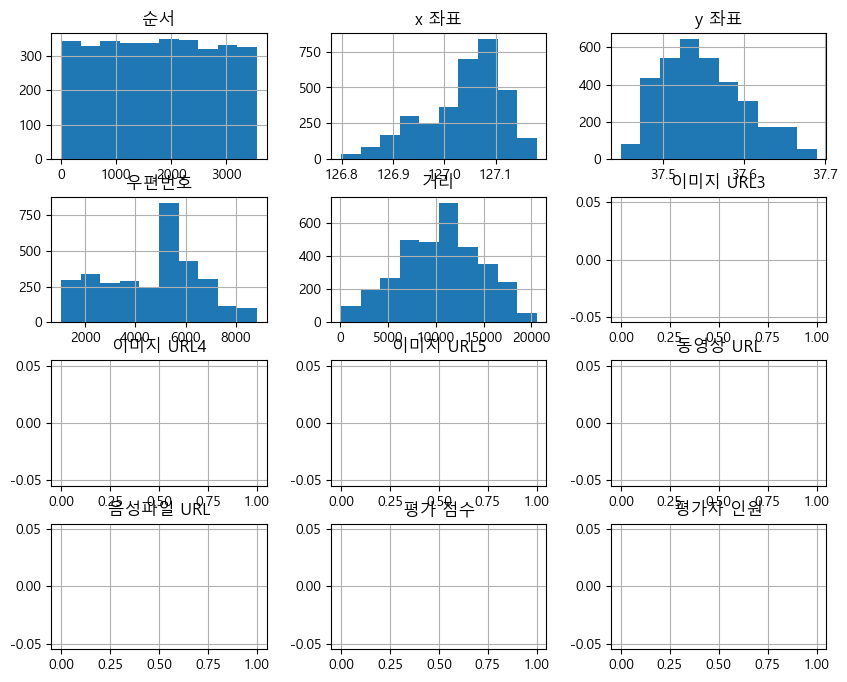

In [18]:
# 각 변수의 분포 확인
# 가로축은 값
# 세로축은 수치
df.hist(figsize=(10, 8))
plt.show()

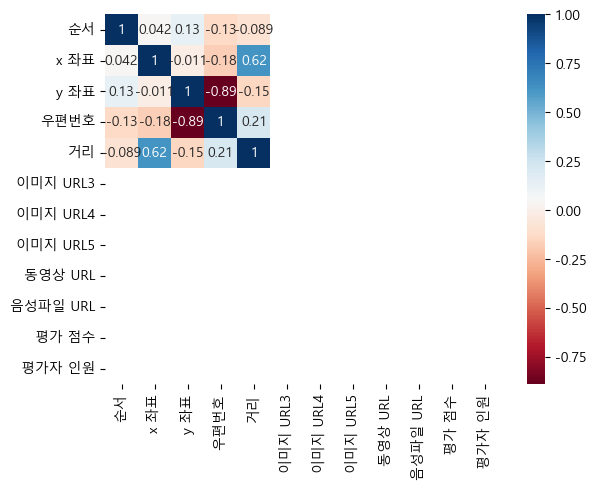

In [20]:
# 변수 간 상관관계 시각화
# 보고서에 제출할때 heatmap을 통해 상관관계표기 **필수
# 다중공산성 
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdBu')
plt.show()

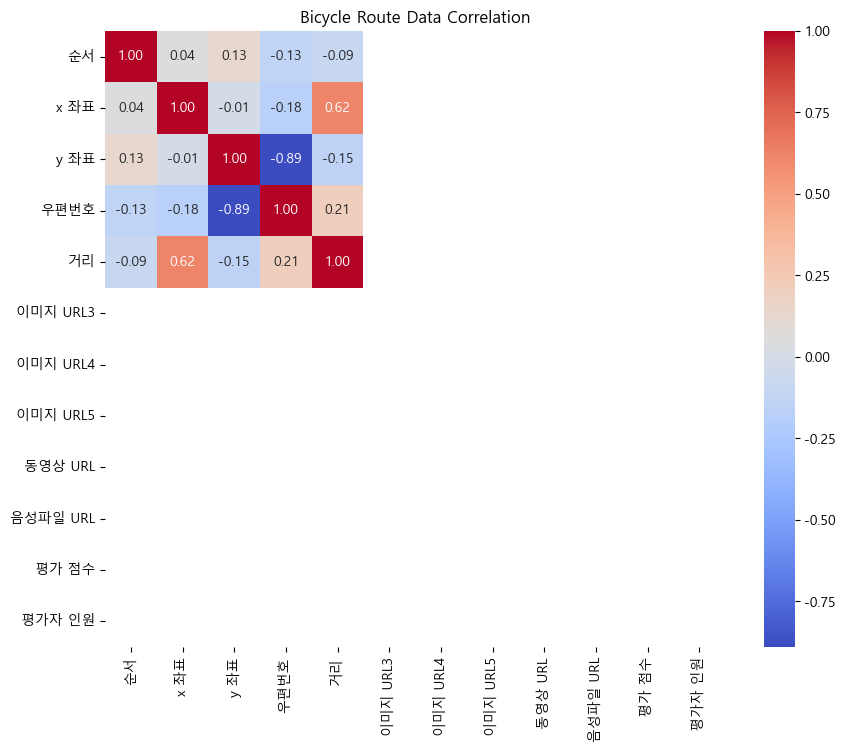

In [ ]:
# 1. 숫자형 데이터가 있는 컬럼들만 리스트로 뽑기
numeric_df = df.select_dtypes(include=['number'])

# 2. 선택된 데이터로 히트맵 그리기
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Bicycle Route Data Correlation")
plt.show()

In [21]:
# 결측치 확인
df.isnull().sum()

순서               0
시설ID             0
컨텐츠 명            0
사용유무             0
테마 타입            0
x 좌표             0
y 좌표             0
좌표 배열            0
좌표타입             2
메인 이미지        3195
새 주소           141
구 주소            22
우편번호           141
국가 지점 번호      1673
테마 명             0
거리               0
업데이트 일           0
등록일              0
이미지 URL1      3195
이미지 URL2      3367
이미지 URL3      3368
이미지 URL4      3368
이미지 URL5      3368
동영상 URL       3368
음성파일 URL      3368
평가 점수         3368
평가자 인원        3368
상세정보 이름 1       16
상세정보 값 1      3022
상세정보 이름 2        0
상세정보 값 2      1060
상세정보 이름 3        3
상세정보 값 3      2512
상세정보 이름 4        0
상세정보 값 4      2389
상세정보 이름 5        3
상세정보 값 5      2270
상세정보 이름 6        0
상세정보 값 6      3345
상세정보 이름 7        1
상세정보 값 7      3352
상세정보 이름 8        4
상세정보 값 8      3361
상세정보 이름 9        5
상세정보 값 9      3357
상세정보 이름 10    2324
상세정보 값 10     2324
dtype: int64

is_24h_inferred (1,742개)의 발견:
분석: 단순히 텍스트에서 추출했을 땐 37개뿐이었던 24시간 시설이, "거치대"라는 도메인 지식을 이용해 추론하니 **1,742개(전체의 약 52%)**로 늘어났습니다.
활용: 이 데이터는 야간 주행 추천 모델의 핵심 변수가 됩니다. "밤 10시 이후 경로 탐색 시, is_24h_inferred 점수가 높은 도로를 우선 추천"하는 로직의 성능이 확 올라갑니다.
has_image (173개)의 희소성:
분석: 전체의 약 5%만이 사진을 가지고 있습니다.
활용: 이 173개는 **'프리미엄 노드(K-Ride Verified)'**로 분류할 수 있습니다. 관광 및 K-POP 코스를 설계할 때, 사진이 있는 검증된 거점을 경유지로 설정하면 사용자 만족도가 높아집니다. (비즈니스 수익 모델: 사진이 없는 상점/시설에 사진 등록 제안 및 광고 유치)
상관계수(Correlation) 결과의 의미:
분석: 히트맵에서 수치들이 대부분 낮게 나옵니다. 이는 '개별 시설 데이터'만으로는 상관관계가 낮다는 뜻입니다.
결론: 이제 **'공간 결합(Spatial Join)'**이 필요합니다. "도로 너비가 좁을수록(도로 데이터) 사고가 많이 나는가?(사고 데이터)" 혹은 "거치대 거리가 멀수록 이용 만족도가 낮은가?"처럼 서로 다른 데이터를 합쳐야 의미 있는 상관관계가 나타날 것입니다.

다음 단계: 머신러닝 학습용 데이터셋 합치기 (가장 중요)
이제 **[도로 데이터] + [편의시설 데이터] + [사고 데이터]**를 하나로 합쳐서 **'안전 점수 예측 모델'**을 만들어야 합니다.
구체적인 방법 (Feature Engineering):
편의시설 밀도: 각 도로(11,771개)의 기점/종점 500m 이내에 편의시설이 몇 개 있는지 카운트하여 amenity_count 컬럼 추가.
사고 위험도: 각 도로 주변 100m 이내에 사고 발생 건수를 합산하여 accident_score 컬럼 추가 (이게 모델의 Target이 됩니다).
최종 ML 데이터셋 구조:
[도로너비, 도로종류, 편의시설수, 24시간시설수, 경사도] ➔ 학습(X)
[사고발생건수] ➔ 예측 정답(Y)

In [22]:
# 결측치 평균값으로 채우기
# 1. 숫자형 컬럼은 '평균값'으로 채우기
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# 2. 범주형(글자) 컬럼은 '최빈값(가장 많이 나온 값)'이나 '미상'으로 채우기
# 예: 자전거도로종류가 비어있으면 '알수없음'으로 채움
char_cols = df.select_dtypes(include=['object']).columns
df[char_cols] = df[char_cols].fillna('미상')

# 확인
print(df.isnull().sum())
df

순서               0
시설ID             0
컨텐츠 명            0
사용유무             0
테마 타입            0
x 좌표             0
y 좌표             0
좌표 배열            0
좌표타입             0
메인 이미지           0
새 주소             0
구 주소             0
우편번호             0
국가 지점 번호         0
테마 명             0
거리               0
업데이트 일           0
등록일              0
이미지 URL1         0
이미지 URL2         0
이미지 URL3      3368
이미지 URL4      3368
이미지 URL5      3368
동영상 URL       3368
음성파일 URL      3368
평가 점수         3368
평가자 인원        3368
상세정보 이름 1        0
상세정보 값 1         0
상세정보 이름 2        0
상세정보 값 2         0
상세정보 이름 3        0
상세정보 값 3         0
상세정보 이름 4        0
상세정보 값 4         0
상세정보 이름 5        0
상세정보 값 5         0
상세정보 이름 6        0
상세정보 값 6         0
상세정보 이름 7        0
상세정보 값 7         0
상세정보 이름 8        0
상세정보 값 8         0
상세정보 이름 9        0
상세정보 값 9         0
상세정보 이름 10       0
상세정보 값 10        0
dtype: int64


,순서,시설ID,컨텐츠 명,사용유무,테마 타입,x 좌표,y 좌표,좌표 배열,좌표타입,메인 이미지,...,상세정보 이름 6,상세정보 값 6,상세정보 이름 7,상세정보 값 7,상세정보 이름 8,상세정보 값 8,상세정보 이름 9,상세정보 값 9,상세정보 이름 10,상세정보 값 10
0,1,공덕전철역 2번출구,자전거 일반거치대,사용,일반,126.950520,37.544413,[],Point,미상,...,운영형태(*수리센터만 선택하세요.),미상,"수리범위(*수리센터만 선택하고, 예, 경정비 무상, 부품교체 실비 등.)",미상,"이동수리센터 순회일정(*이동수리센터만 입력, 예) 자치구 순회일정 안내 게시판 링크)",미상,"유의사항(예, O0학교 운영시간 외 이용불가 )",미상,마포구청 교통행정과,마포구청 교통행정과
1,2,강남구_거치대_003,IBK기업은행 도곡팰리스 옆,사용,일반,127.050743,37.487111,"[127.05074346028596,37.48711080157728]",Point,미상,...,운영형태(*수리센터만 선택하세요.),미상,"수리범위(*수리센터만 선택하고, 예, 경정비 무상, 부품교체 실비 등.)",미상,"이동수리센터 순회일정(*이동수리센터만 입력, 예) 자치구 순회일정 안내 게시판 링크)",미상,"유의사항(예, O0학교 운영시간 외 이용불가 )",미상,강남구청 교통행정과,강남구청 교통행정과
2,3,11103419_1742732593843,갈말근린공원,사용,일반,127.053270,37.665810,"[127.05327,37.66581]",Point,https://map.seoul.go.kr/smgis/ucimgs/conts/111...,...,운영형태(*수리센터만 선택하세요.),미상,"수리범위(*수리센터만 선택하고, 예, 경정비 무상, 부품교체 실비 등.)",미상,"이동수리센터 순회일정(*이동수리센터만 입력, 예) 자치구 순회일정 안내 게시판 링크)",미상,"유의사항(예, O0학교 운영시간 외 이용불가 )",미상,노원구청 탄소중립도시과,노원구청 탄소중립도시과
3,4,강남구_거치대_004,강남구도시관리공단앞,사용,일반,127.051807,37.516347,"[127.05180733843014,37.516347047795094]",Point,미상,...,운영형태(*수리센터만 선택하세요.),미상,"수리범위(*수리센터만 선택하고, 예, 경정비 무상, 부품교체 실비 등.)",미상,"이동수리센터 순회일정(*이동수리센터만 입력, 예) 자치구 순회일정 안내 게시판 링크)",미상,"유의사항(예, O0학교 운영시간 외 이용불가 )",미상,강남구청 교통행정과,강남구청 교통행정과
4,5,강남구_거치대_005,강남구립개포꿈하늘도서관,사용,일반,127.080635,37.490793,"[127.08063461397037,37.49079289480145]",Point,미상,...,운영형태(*수리센터만 선택하세요.),미상,"수리범위(*수리센터만 선택하고, 예, 경정비 무상, 부품교체 실비 등.)",미상,"이동수리센터 순회일정(*이동수리센터만 입력, 예) 자치구 순회일정 안내 게시판 링크)",미상,"유의사항(예, O0학교 운영시간 외 이용불가 )",미상,강남구청 교통행정과,강남구청 교통행정과
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3363,3549,용산구 거치대 정류소-04,후암동버스종점 자전거보관소,사용,일반,126.981199,37.546589,"[126.981199173,37.546589065]",Point,미상,...,운영형태(*수리센터만 선택하세요.),미상,"수리범위(*수리센터만 선택하고, 예, 경정비 무상, 부품교체 실비 등.)",미상,"이동수리센터 순회일정(*이동수리센터만 입력, 예) 자치구 순회일정 안내 게시판 링크)",미상,"유의사항(예, O0학교 운영시간 외 이용불가 )",미상,미상,미상
3364,3550,용산구 공기주입기 - 046,후암시장삼거리 공기주입기,사용,일반,126.977171,37.550339,"[126.977171219,37.55033894]",Point,미상,...,운영형태(*수리센터만 선택하세요.),미상,"수리범위(*수리센터만 선택하고, 예, 경정비 무상, 부품교체 실비 등.)",미상,"이동수리센터 순회일정(*이동수리센터만 입력, 예) 자치구 순회일정 안내 게시판 링크)",미상,"유의사항(예, O0학교 운영시간 외 이용불가 )",미상,미상,미상
3365,3551,용산구 거치대 도로변 -01,후암시장삼거리 자전거보관소,사용,일반,126.977137,37.550343,"[126.977137226,37.550343296]",Point,미상,...,운영형태(*수리센터만 선택하세요.),미상,"수리범위(*수리센터만 선택하고, 예, 경정비 무상, 부품교체 실비 등.)",미상,"이동수리센터 순회일정(*이동수리센터만 입력, 예) 자치구 순회일정 안내 게시판 링크)",미상,"유의사항(예, O0학교 운영시간 외 이용불가 )",미상,미상,미상
3366,3552,강남구_거치대_299,휘문고등학교,사용,일반,127.062352,37.504559,"[127.06235183733162,37.50455851647241]",Point,미상,...,운영형태(*수리센터만 선택하세요.),미상,"수리범위(*수리센터만 선택하고, 예, 경정비 무상, 부품교체 실비 등.)",미상,"이동수리센터 순회일정(*이동수리센터만 입력, 예) 자치구 순회일정 안내 게시판 링크)",미상,"유의사항(예, O0학교 운영시간 외 이용불가 )",미상,강남구청 교통행정과,강남구청 교통행정과


###Seaborn 함수

서울시 자전거 편의시설 맞춤형 시각화 코드
이 코드를 실행하면 편의시설이 서울 어디에 분포해 있는지, 시설 종류별 특징은 무엇인지 한눈에 볼 수 있습니다.

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pdㄴ

# 1. 한글 폰트 및 마이너스 깨짐 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 (현재 사용 중인 파일)
df = pd.read_csv('../raw_ml/seoul_bicycle_amenities_ml_features.csv')

# 3. [안전 장치] 필요한 컬럼이 없는 경우 즉석에서 생성
if 'has_image' not in df.columns:
    df['has_image'] = df['메인 이미지'].notnull().astype(int)

if 'is_24h_inferred' not in df.columns:
    # '24시간' 키워드 추출 로직
    df['is_24h_inferred'] = df['상세정보 이름 1'].apply(
        lambda x: 1 if any(k in str(x) for k in ['24시간', '24시', '상시', '연중']) else 0
    )
    # 거치대는 기본적으로 24시간으로 간주
    df.loc[df['컨텐츠 명'].str.contains('거치대'), 'is_24h_inferred'] = 1

print("사용 가능한 컬럼 목록:", df.columns.tolist())

사용 가능한 컬럼 목록: ['순서', '시설ID', '컨텐츠 명', '사용유무', '테마 타입', 'x 좌표', 'y 좌표', '좌표 배열', '좌표타입', '메인 이미지', '새 주소', '구 주소', '우편번호', '국가 지점 번호', '테마 명', '거리', '업데이트 일', '등록일', '이미지 URL1', '이미지 URL2', '상세정보 이름 1', '상세정보 값 1', '상세정보 이름 2', '상세정보 값 2', '상세정보 이름 3', '상세정보 값 3', '상세정보 이름 4', '상세정보 값 4', '상세정보 이름 5', '상세정보 값 5', '상세정보 이름 6', '상세정보 값 6', '상세정보 이름 7', '상세정보 값 7', '상세정보 이름 8', '상세정보 값 8', '상세정보 이름 9', '상세정보 값 9', '상세정보 이름 10', '상세정보 값 10', 'has_image', 'is_24h', 'has_restricted_hours', 'is_24h_inferred']


시각화 결과 분석 및 문제점 (핵심 인사이트)
문제점 1: 범례(Legend)의 과부하
그래프 우측의 '컨텐츠 명' 목록이 너무 길어서 읽을 수가 없죠? 이는 '컨텐츠 명' 컬럼에 **너무 세부적인 이름(예: 공덕역 2번출구, 어느 아파트 앞...)**이 섞여 있기 때문입니다.
ML 관점: 머신러닝 학습 시 범주(Category)가 너무 많으면 모델이 복잡해지고 성능이 떨어집니다. 이를 **'일반화'**해야 합니다.
문제점 2: 이진 데이터(0과 1)의 분포
has_image와 is_24h_inferred 그래프를 보면 점들이 0과 1에 일직선으로 몰려 있습니다. 이는 정상적인 현상이지만, 이를 통해 **"어떤 종류의 시설이 주로 사진을 가지고 있나?"**를 파악하는 것이 우리의 목표입니다.


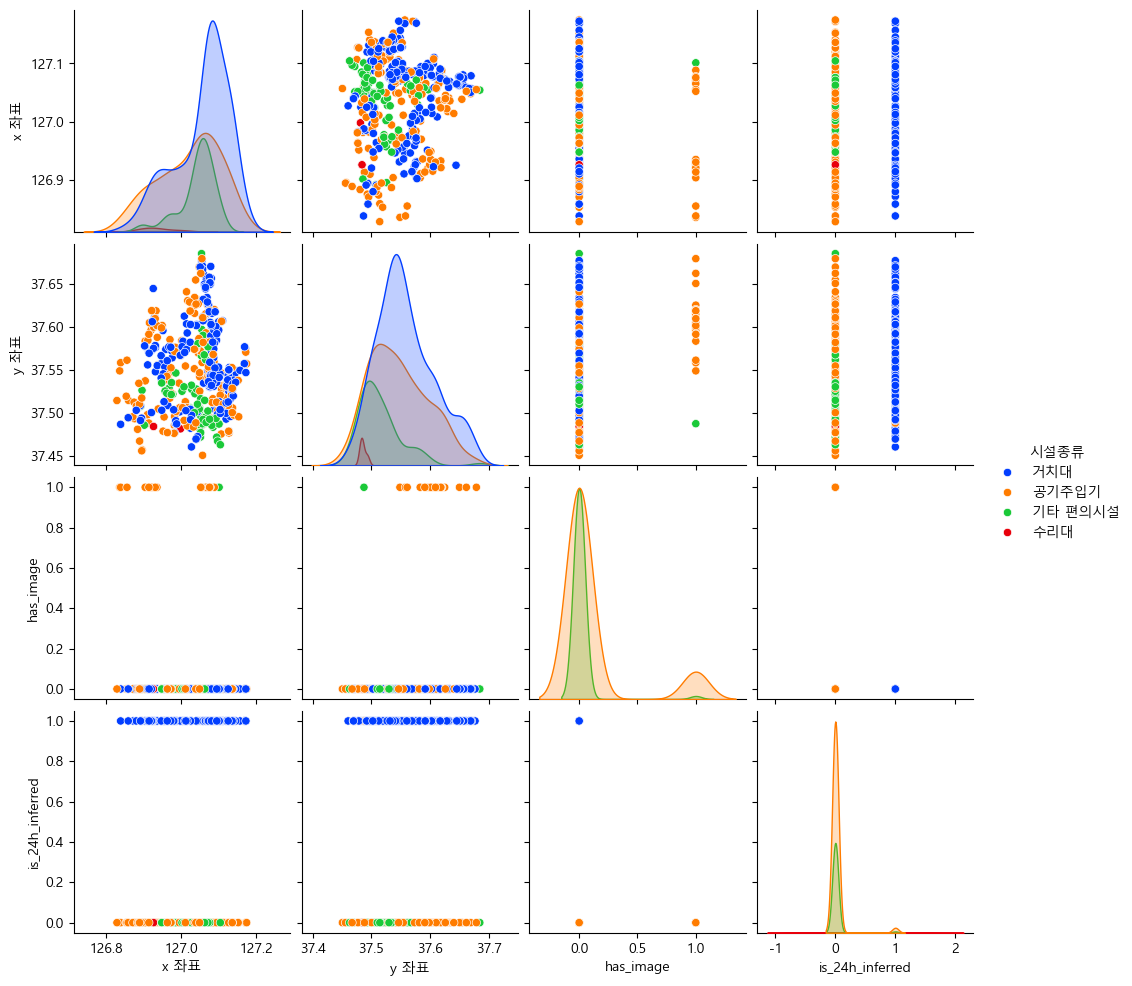

In [30]:
# 1. '컨텐츠 명'에서 핵심 키워드만 추출해서 그룹화하기
def categorize_amenity(name):
    if '거치대' in name: return '거치대'
    elif '주입기' in name: return '공기주입기'
    elif '수리' in name: return '수리대'
    elif '대여' in name: return '대여소'
    else: return '기타 편의시설'

df['시설종류'] = df['컨텐츠 명'].apply(categorize_amenity)

# 2. 그룹화된 데이터로 다시 시각화 (범례가 아주 깔끔해집니다)
sns.pairplot(df.sample(500), 
             vars=['x 좌표', 'y 좌표', 'has_image', 'is_24h_inferred'], 
             hue='시설종류', 
             palette='bright')
plt.show()

 현재 대기 중인 ydata_profiling 셀에 대하여
화면 하단에 있는 탐색적 데이터 분석(EDA) 셀은 매우 강력한 도구입니다.
질문: "이 자전거 도로(Route) 주변 300m 이내에 수리대(Amenity)가 있는가?"
방법: 도로의 위경도와 시설의 위경도를 매칭하여 **[도로 + 시설 정보]**가 합쳐진 하나의 거대한 데이터셋을 만듭니다.
결과: 이 데이터셋으로 **"안전하고 편리한 길 추천 머신러닝"**을 학습시킬 수 있습니다.
지금 바로 하단의 프로파일링 셀을 실행해 보시겠어요? 보고서가 생성되면 그 결과에서 가장 놀라운 수치(예: "이 데이터는 결측치가 너무 많다"는 경고 등)를 알려주세요. 그게 다음 전처리의 힌트가 됩니다!
보고서 확인: 코드가 완료되면 report/ 폴더 안에 HTML 파일이 생깁니다.
팁: VS Code 왼쪽 탐색기에서 해당 HTML 파일을 우클릭하고 [Open with Live Server] 또는 **[Reveal in File Explorer]**로 열어 크롬 브라우저에서 확인해 보세요.
여기서 'Correlations(상관계수)' 탭을 보시면 우리가 짠 코드보다 훨씬 정밀한 분석 결과를 볼 수 있습니다.

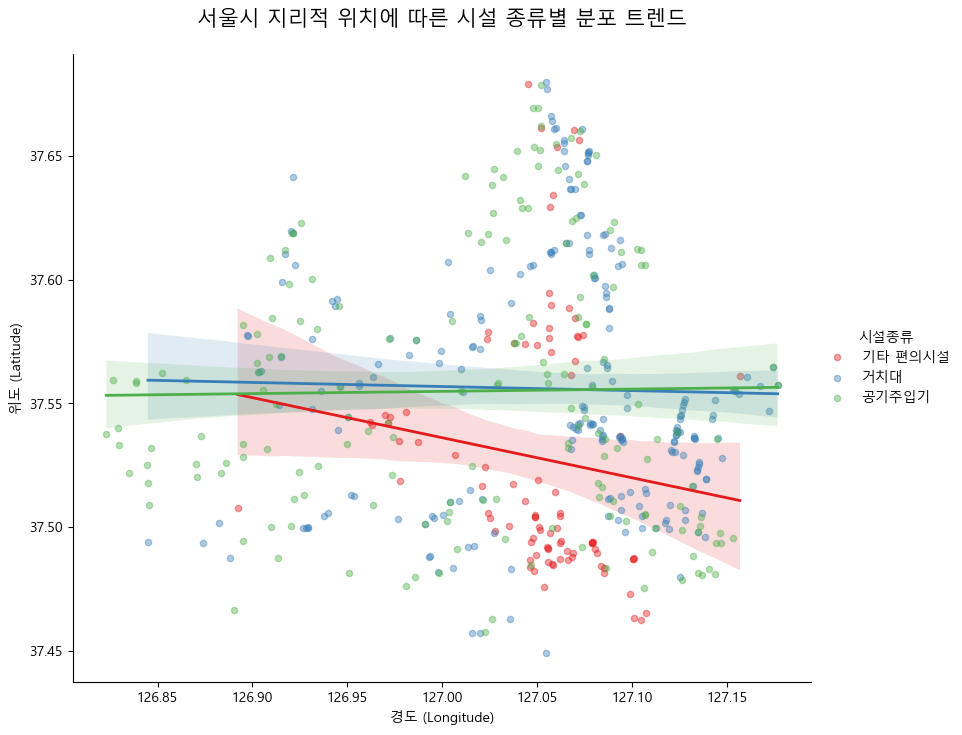

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. [필수] 시설 종류 그룹화 (혹시 앞에서 안 하셨다면 다시 실행)
def categorize_amenity(name):
    if '거치대' in name: return '거치대'
    elif '주입기' in name: return '공기주입기'
    elif '수리' in name: return '수리대'
    elif '대여' in name: return '대여소'
    else: return '기타 편의시설'

if '시설종류' not in df.columns:
    df['시설종류'] = df['컨텐츠 명'].apply(categorize_amenity)

# 2. 데이터 샘플링 (시각화 품질을 위해 300~500개 권장)
df_lm_sample = df.sample(n=500, random_state=42) if len(df) > 500 else df

# 3. Lmplot 실행 (hue를 '시설종류'로 변경)
sns.lmplot(x='x 좌표', y='y 좌표', data=df_lm_sample, 
           hue='시설종류',          # <--- 이 부분이 핵심입니다!
           palette='Set1',        # 가독성 좋은 팔레트
           height=7, aspect=1.2, 
           scatter_kws={'alpha':0.4, 's':20}, # 점 투명도와 크기 조절
           line_kws={'linewidth': 2})         # 회귀선 굵기 조절

plt.title('서울시 지리적 위치에 따른 시설 종류별 분포 트렌드', fontsize=15, pad=20)
plt.xlabel('경도 (Longitude)')
plt.ylabel('위도 (Latitude)')

plt.show()

### 탐색적 데이터 분석(EDA)

In [2]:
import os
import pandas as pd
from ydata_profiling import ProfileReport

# 1. 보고서를 저장할 폴더 생성 (없으면 자동 생성)
if not os.path.exists('report'):
    os.makedirs('report')
    print("report 폴더를 생성했습니다.")

# 2. 데이터 불러오기
file_path = '../raw_ml/seoul_bicycle_amenities_ml_features.csv'
try:
    df = pd.read_csv(file_path)
    print("데이터 로드 성공!")
except Exception as e:
    print(f"파일 로드 실패: {e}")

# 3. YData Profiling 보고서 생성
# title을 프로젝트 명으로, 관측 모드(explorative) 활성화
profile = ProfileReport(df, title="K-Ride 자전거 도로 편의시설 분석 보고서", explorative=True)

# 4. HTML 파일로 저장 (파일명 수정)
output_file = 'report/bicycle_data_facility_profiling_report.html'
profile.to_file(output_file)

print(f"✅ 프로파일링 보고서가 생성되었습니다: {os.path.abspath(output_file)}")

데이터 로드 성공!


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 43/43 [00:01<00:00, 30.66it/s]
c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\.venv\lib\site-packages\ydata_profiling\visualisation\utils.py:73: UserWarning: Glyph 49692 (\N{HANGUL SYLLABLE SUN}) missing from font(s) Arial.
  plt.savefig(
c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\.venv\lib\site-packages\ydata_profiling\visualisation\utils.py:73: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) Arial.
  plt.savefig(
c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\.venv\lib\site-packages\ydata_profiling\visualisation\utils.py:73: UserWarning: Glyph 51340 (\N{HANGUL SYLLABLE JWA}) missing from font(s) Arial.
  plt.savefig(
c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\.venv\lib\site-packages\ydata_profiling\visualisation\utils.py:73: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) Arial.
  plt.savefig(
c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\.venv\lib\site-pac

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\.venv\lib\site-packages\ydata_profiling\visualisation\utils.py:73: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) Arial.
  plt.savefig(
c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\.venv\lib\site-packages\ydata_profiling\visualisation\utils.py:73: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) Arial.
  plt.savefig(
c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\.venv\lib\site-packages\ydata_profiling\visualisation\utils.py:73: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) Arial.
  plt.savefig(
c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\.venv\lib\site-packages\ydata_profiling\visualisation\utils.py:73: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) Arial.
  plt.savefig(
c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\.venv\lib\site-packages\ydata_profiling\visualisation\utils.py:73: 

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

✅ 프로파일링 보고서가 생성되었습니다: c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\kride-project\report\bicycle_data_facility_profiling_report.html


1순위: 자전거 도로 + 사고 데이터 결합 (Labeling)
목표: df_clean (도로 데이터)의 각 행에 accident_count (사고 건수) 컬럼 추가.
방법:
사고 데이터를 불러옵니다.
특정 도로(기점/종점) 좌표 반경 100m 이내에 사고 좌표가 몇 개 있는지 카운트합니다.
이게 머신러닝의 **정답(Target)**이 됩니다.
2순위: 외부 API 연동 피처 생성 (Feature Engineering)
날씨 데이터 추가: pd.merge를 이용해 사고 날짜와 기상 데이터를 합칩니다. "비 오는 날 + 폭이 좁은 도로"라는 복합적인 위험 신호를 모델이 학습하게 합니다.
고도 데이터 추가: Google Elevation API 등을 사용해 기점/종점의 고도값을 가져와 slope 컬럼을 만듭니다.

추천하는 머신러닝 알고리즘
도로 안전도 예측: XGBoost 또는 LightGBM (수치형 데이터 처리에 가장 강력하며, 도로 폭/경사도/사고건수 간의 관계를 잘 찾아냅니다.)
경로 추천: Content-based Filtering (사용자가 선택한 태그와 경로의 POI 정보를 매칭.)



XGBoost(eXtreme Gradient Boosting)는 머신러닝에서 예측 성능이 매우 뛰어난 알고리즘입니다.

쉽게 설명하자면 **'오답 노트를 꼼꼼히 쓰는 전문가 팀'**과 같습니다. 🧠 첫 번째 모델(결정 트리)이 문제를 풀고 틀린 문제(오차)를 정리하면, 두 번째 모델은 그 틀린 문제만 집중적으로 학습해서 풉니다. 세 번째 모델은 앞선 두 모델이 놓친 부분을 다시 학습합니다. 이렇게 여러 모델이 앞선 모델의 실수를 차례대로 보완하며 이어달리기를 하는 방식을 '부스팅(Boosting)'이라고 합니다. XGBoost는 이 과정을 아주 빠르고 효율적으로 수행하도록 한 단계 발전시킨 기술입니다.

이 알고리즘은 표 형태(엑셀, CSV 등)의 데이터를 다룰 때 속도와 정확도가 압도적이어서 실무는 물론 데이터 분석 대회(Kaggle 등)에서도 가장 많이 쓰이는 핵심 무기

1. 앙상블 (Ensemble)
앙상블은 '여러 명의 전문가가 의견을 모아 최종 결정을 내리는 방식'입니다. 한 명의 의사에게 진료를 받는 것보다, 각기 다른 경험을 가진 의사 10명이 모여 회의를 통해 병을 진단하는 것이 오진 확률을 줄이고 훨씬 정확한 것과 같은 원리입니다. 머신러닝에서는 여러 개의 약한 예측 모델(Weak Learner)을 결합하여 하나의 강력한 모델(Strong Learner)을 만드는 것을 의미합니다.

2. 부스팅 (Boosting)
부스팅은 앙상블을 구현하는 대표적인 기법 중 하나로, 모델들이 **'순차적'**으로 학습한다는 점이 핵심입니다.

첫 번째 모델이 데이터를 학습하고 예측을 수행한 뒤, 틀린 문제(오차)를 확인합니다.

두 번째 모델은 첫 번째 모델이 틀린 문제에만 높은 가중치를 두고 집중적으로 다시 학습합니다.

세 번째 모델은 두 번째 모델이 놓친 부분에 다시 집중합니다.

이렇게 앞선 모델의 약점을 다음 모델이 계속해서 보완해 나가는 이어달리기 방식입니다. XGBoost는 이 오차를 수학적으로 정교하게 추적하고(Gradient), 그 연산 속도와 효율을 극도로 끌어올린(eXtreme) 알고리즘입니다.